# First CNN for Genre Classification

## Goal

Prepare Mel-spectrograms as image-like tensors and train a first simple convolutional neural network for music genre classification.

## Why Convolutional Neural Networks?

In previous notebooks, each audio file was represented by a small set of handcrafted features such as MFCCs.

While this approach is simple and efficient, it reduces the amount of information available to the model.

Convolutional Neural Networks (CNNs) can instead learn patterns directly from Mel-spectrograms.

Because Mel-spectrograms resemble images, CNNs can detect local structures such as:

- harmonics
- frequency bands
- rhythmic patterns
- genre-specific textures

This allows the model to learn more complex representations than traditional feature engineering.

In [16]:
import numpy as np
import librosa
from pathlib import Path
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
from torch.utils.data import TensorDataset, DataLoader

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

In [17]:
data_path = Path("../data/raw/gtzan/Data/genres_original")

genres = ["rock", "classical", "jazz", "metal"]
samples_per_genre = 50

## 1. Converting Audio into CNN Inputs

Neural networks require inputs with consistent dimensions.

Therefore, each audio file is converted into a Mel-spectrogram with a fixed size.

The resulting Mel-spectrogram can be interpreted as a grayscale image:

- width = time
- height = frequency
- color intensity = energy

In [18]:
def compute_mel(file_path, target_frames=130):
    y, sr = librosa.load(file_path, sr=22050)

    mel = librosa.feature.melspectrogram(
        y=y,
        sr=sr,
        n_mels=128
    )

    mel_db = librosa.power_to_db(mel, ref=np.max)

    if mel_db.shape[1] >= target_frames:
        mel_db = mel_db[:, :target_frames]
    else:
        pad_width = target_frames - mel_db.shape[1]
        mel_db = np.pad(mel_db, ((0, 0), (0, pad_width)), mode="constant")

    return mel_db

The Mel-spectrograms are resized to a fixed number of frames.

This ensures that all samples have identical dimensions and can be processed in batches by the neural network.

## 2. Building the Dataset

We now generate Mel-spectrograms for all selected audio files.

Each spectrogram becomes one training sample, while the genre name serves as the target label.

In [19]:
X = []
y = []

for genre in genres:
    genre_path = data_path / genre
    files = list(genre_path.glob("*.wav"))[:samples_per_genre]

    for file in files:
        mel = compute_mel(file)
        X.append(mel)
        y.append(genre)

X = np.array(X)
y = np.array(y)

print("X shape before normalization:", X.shape)
print("y shape:", y.shape)

X shape before normalization: (200, 128, 130)
y shape: (200,)


The resulting dataset contains one Mel-spectrogram per song.

At this stage, the data still consists of raw feature values and has not yet been normalized.

## 3. Data Normalization

Neural networks generally train more effectively when input values are normalized.

Here, we standardize the dataset so that it has approximately:

- mean = 0
- standard deviation = 1

This helps stabilize gradient updates during training.

In [20]:
X = (X - X.mean()) / X.std()

print("Mean after normalization:", X.mean())
print("Std after normalization:", X.std())

Mean after normalization: 0.0
Std after normalization: 0.99999994


## 4. Preparing CNN Input Shapes

PyTorch expects image-like data in the format:

(batch_size, channels, height, width)

Since Mel-spectrograms are grayscale images, we add a single channel dimension.

In [21]:
X = X[:, np.newaxis, :, :]

print("CNN input shape:", X.shape)

CNN input shape: (200, 1, 128, 130)


## 5. Encoding Genre Labels

Neural networks operate on numerical targets rather than text labels.

Therefore, genre names are converted into integer class indices.

In [22]:
encoder = LabelEncoder()
y_encoded = encoder.fit_transform(y)

print("Classes:", encoder.classes_)
print("Encoded labels example:", y_encoded[:10])

Classes: ['classical' 'jazz' 'metal' 'rock']
Encoded labels example: [3 3 3 3 3 3 3 3 3 3]


## 6. Train/Test Split

To evaluate generalization performance, we split the dataset into training and test subsets.

The model only learns from the training set and is evaluated on previously unseen samples.

In [23]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y_encoded,
    test_size=0.2,
    random_state=42,
    stratify=y_encoded
)

## 7. Converting Data to PyTorch Tensors

PyTorch models operate on tensors rather than NumPy arrays.

The data is therefore converted into tensor representations before training.

In [24]:
X_train = torch.tensor(X_train, dtype=torch.float32)
X_test = torch.tensor(X_test, dtype=torch.float32)

y_train = torch.tensor(y_train, dtype=torch.long)
y_test = torch.tensor(y_test, dtype=torch.long)

train_dataset = TensorDataset(X_train, y_train)
test_dataset = TensorDataset(X_test, y_test)

train_loader = DataLoader(train_dataset, batch_size=8, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=8)

## 8. CNN Architecture

The network consists of:

1. Convolutional layers for feature extraction
2. ReLU activation functions
3. Pooling layers for dimensionality reduction
4. Fully connected layers for classification

The convolutional layers automatically learn local patterns in the Mel-spectrograms.

These learned patterns may correspond to musical structures such as harmonics, timbre, or rhythmic elements.

In [25]:
class SimpleCNN(nn.Module):

    def __init__(self, num_classes):
        super().__init__()

        self.conv_layers = nn.Sequential(
            nn.Conv2d(1, 8, kernel_size=3),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(8, 16, kernel_size=3),
            nn.ReLU(),
            nn.MaxPool2d(2)
        )

        self.flatten = nn.Flatten()

        self.classifier = nn.Sequential(
            nn.Linear(16 * 30 * 31, 64),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(64, num_classes)
        )

    def forward(self, x):
        x = self.conv_layers(x)
        x = self.flatten(x)
        x = self.classifier(x)
        return x

In [26]:
model = SimpleCNN(num_classes=len(genres))

criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

print(model)

SimpleCNN(
  (conv_layers): Sequential(
    (0): Conv2d(1, 8, kernel_size=(3, 3), stride=(1, 1))
    (1): ReLU()
    (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (3): Conv2d(8, 16, kernel_size=(3, 3), stride=(1, 1))
    (4): ReLU()
    (5): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (flatten): Flatten(start_dim=1, end_dim=-1)
  (classifier): Sequential(
    (0): Linear(in_features=14880, out_features=64, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.3, inplace=False)
    (3): Linear(in_features=64, out_features=4, bias=True)
  )
)


The model architecture can be inspected above.

The number of trainable parameters is still relatively small, making this network suitable as a first CNN baseline.

## 9. Model Training

The model is trained using:

- Cross Entropy Loss
- Adam optimizer
- Mini-batch gradient descent

During training, the network gradually adjusts its parameters to reduce classification errors.

In [27]:
num_epochs = 20
loss_history = []

for epoch in range(num_epochs):
    model.train()
    total_loss = 0

    for X_batch, y_batch in train_loader:
        optimizer.zero_grad()

        outputs = model(X_batch)
        loss = criterion(outputs, y_batch)

        loss.backward()
        optimizer.step()

        total_loss += loss.item()

    avg_loss = total_loss / len(train_loader)
    loss_history.append(avg_loss)

    print(f"Epoch {epoch+1}/{num_epochs}, Loss: {avg_loss:.4f}")

Epoch 1/20, Loss: 1.2785
Epoch 2/20, Loss: 0.9545
Epoch 3/20, Loss: 0.6372
Epoch 4/20, Loss: 0.5250
Epoch 5/20, Loss: 0.3569
Epoch 6/20, Loss: 0.2837
Epoch 7/20, Loss: 0.1858
Epoch 8/20, Loss: 0.1484
Epoch 9/20, Loss: 0.1072
Epoch 10/20, Loss: 0.1173
Epoch 11/20, Loss: 0.0542
Epoch 12/20, Loss: 0.0558
Epoch 13/20, Loss: 0.0553
Epoch 14/20, Loss: 0.0339
Epoch 15/20, Loss: 0.0298
Epoch 16/20, Loss: 0.0229
Epoch 17/20, Loss: 0.0294
Epoch 18/20, Loss: 0.0154
Epoch 19/20, Loss: 0.0251
Epoch 20/20, Loss: 0.0447


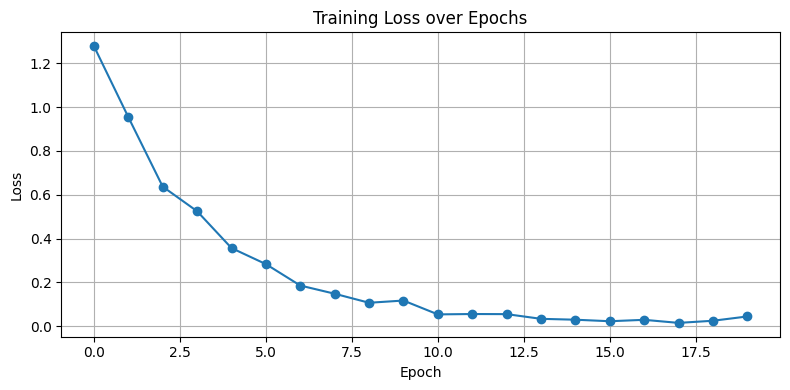

In [28]:
plt.figure(figsize=(8, 4))
plt.plot(loss_history, marker="o")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training Loss over Epochs")
plt.grid(True)
plt.tight_layout()
plt.show()

The training loss should generally decrease over time.

A decreasing loss indicates that the network is successfully learning patterns from the training data.

## 10. Model Evaluation

After training, we evaluate the model on the test set.

This provides an estimate of how well the learned patterns generalize to unseen audio samples.

In [29]:
model.eval()

all_preds = []
all_labels = []

with torch.no_grad():
    for X_batch, y_batch in test_loader:
        outputs = model(X_batch)
        preds = torch.argmax(outputs, dim=1)

        all_preds.extend(preds.numpy())
        all_labels.extend(y_batch.numpy())

all_preds = np.array(all_preds)
all_labels = np.array(all_labels)

accuracy = np.mean(all_preds == all_labels)
print("Test Accuracy:", accuracy)

Test Accuracy: 0.85


### Classification Report

Precision, recall, and F1-score provide a more detailed view of model performance than accuracy alone.

In [32]:
from sklearn.metrics import classification_report

print(
    classification_report(
        all_labels,
        all_preds,
        target_names=encoder.classes_
    )
)

              precision    recall  f1-score   support

   classical       0.82      0.90      0.86        10
        jazz       0.88      0.70      0.78        10
       metal       0.91      1.00      0.95        10
        rock       0.80      0.80      0.80        10

    accuracy                           0.85        40
   macro avg       0.85      0.85      0.85        40
weighted avg       0.85      0.85      0.85        40



### Confusion Matrix

The confusion matrix helps identify which genres are frequently confused by the model.

Correct predictions appear along the diagonal.

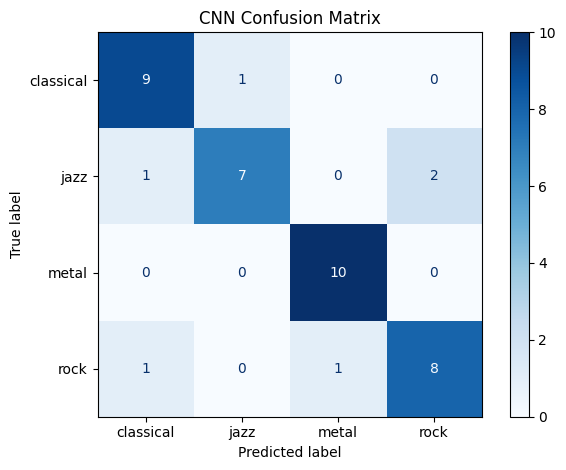

In [31]:
cm = confusion_matrix(all_labels, all_preds)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=encoder.classes_
)

disp.plot(cmap="Blues")
plt.title("CNN Confusion Matrix")
plt.tight_layout()
plt.show()

## CNNs vs. Classical Machine Learning

Unlike Random Forests, CNNs do not provide simple feature importance values.

Instead, the network learns hierarchical representations automatically from the Mel-spectrograms.

This makes CNNs more powerful, but also less interpretable.

## Observations

- The dataset consists of 200 audio samples from four genres (rock, classical, jazz, and metal).
- Each audio file was converted into a Mel-spectrogram with a fixed shape of 128 × 130.
- The spectrograms were normalized to zero mean and unit variance, which improves training stability.
- The data was reshaped to the format (samples, channels, height, width) required by convolutional neural networks.
- During training, the loss consistently decreased from approximately 1.28 to 0.02.
- The CNN achieved a test accuracy of approximately 85%.
- The CNN outperformed the previous Random Forest baseline (~79% accuracy).

## Interpretation

The improved accuracy suggests that using complete Mel-spectrograms provides more useful information than using only aggregated MFCC features.

Unlike the Random Forest model, the CNN learns feature representations directly from the data instead of relying on handcrafted features.

The strong decrease in training loss may indicate the beginning of overfitting, as the network fits the training data extremely well.

Overall, the results demonstrate the potential of deep learning methods for music genre classification.

## Week 6 Summary

This week introduced the first deep learning model of the project.

We:

- converted audio files into fixed-size Mel-spectrograms
- normalized the dataset
- prepared image-like tensors for PyTorch
- encoded genre labels
- trained a convolutional neural network
- evaluated performance using classification metrics and a confusion matrix

Unlike previous approaches, the CNN learns useful representations directly from the data rather than relying on handcrafted features.

This notebook marks the transition from classical machine learning to deep learning for music genre classification.